In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [ ]:
# Load MNIST
(x_train_orig, y_train_orig), (x_test_orig, y_test_orig) = mnist.load_data()

# Combine all samples
X = np.concatenate((x_train_orig, x_test_orig))
y = np.concatenate((y_train_orig, y_test_orig))

# Small split to encourage overfitting
x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    train_size=5000,
    test_size=1000,
    random_state=42,
    stratify=y
)

print("Train:", x_train.shape)
print("Test :", x_test.shape)

# Normalize
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Flatten
x_train = x_train.reshape(-1, 784)
x_test  = x_test.reshape(-1, 784)

Train: (5000, 28, 28)
Test : (1000, 28, 28)


In [ ]:
def build_model():

    model = keras.Sequential([
        layers.Dense(784, input_shape=(784,)),
        layers.Dense(256, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])

    return model

Early Stopping

In [ ]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [ ]:
class LRRecorder(keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.lrs = []

    def on_epoch_end(self, epoch, logs=None):
        lr = self.model.optimizer.learning_rate
        if hasattr(lr, "numpy"):
            lr = lr.numpy()
        self.lrs.append(lr)

In [ ]:
model_fixed = build_model()

lr_fixed_rec = LRRecorder()

model_fixed.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

hist_fixed = model_fixed.fit(
    x_train, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop, lr_fixed_rec]
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.6544 - loss: 1.1140 - val_accuracy: 0.8690 - val_loss: 0.4102
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8968 - loss: 0.3264 - val_accuracy: 0.8900 - val_loss: 0.3196
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9438 - loss: 0.1916 - val_accuracy: 0.9150 - val_loss: 0.2575
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9587 - loss: 0.1437 - val_accuracy: 0.9270 - val_loss: 0.2233
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9767 - loss: 0.0891 - val_accuracy: 0.9260 - val_loss: 0.2385
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9760 - loss: 0.0846 - val_accuracy: 0.9140 - val_loss: 0.2566
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9862 - loss: 0.0599 - val_accuracy: 0.9290 - val_loss: 0.2371
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9915 - loss: 0.0416 - val_accuracy: 0.9280 - val_loss: 0.

In [ ]:
def step_decay(epoch):

    if epoch < 10:
        return 0.001
    elif epoch < 20:
        return 0.0005
    else:
        return 0.0001


lr_scheduler = keras.callbacks.LearningRateScheduler(step_decay)
lr_step_rec = LRRecorder()

model_step = build_model()

model_step.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

hist_step = model_step.fit(
    x_train, y_train,
    epochs=25,
    batch_size=128,
    validation_split=0.2,
    callbacks=[lr_scheduler, early_stop, lr_step_rec]
)

Epoch 1/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.6495 - loss: 1.1479 - val_accuracy: 0.8940 - val_loss: 0.3610 - learning_rate: 0.0010
Epoch 2/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9121 - loss: 0.2913 - val_accuracy: 0.9080 - val_loss: 0.2806 - learning_rate: 0.0010
Epoch 3/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9366 - loss: 0.2110 - val_accuracy: 0.9110 - val_loss: 0.2889 - learning_rate: 0.0010
Epoch 4/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9677 - loss: 0.1223 - val_accuracy: 0.9030 - val_loss: 0.3116 - learning_rate: 0.0010
Epoch 5/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9672 - loss: 0.1027 - val_accuracy: 0.9280 - val_loss: 0.2391 - learning_rate: 0.0010
Epoch 6/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9809 - loss: 0.0665 - val_accuracy: 0.9260 - val_loss: 0.2481 - learning_rate: 0.0010
Epoch 7/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9879 - loss: 0.0489 - val_acc

In [ ]:
lr_exp = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=1000,
    decay_rate=0.9
)

lr_exp_rec = LRRecorder()

model_exp = build_model()

model_exp.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_exp),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

hist_exp = model_exp.fit(
    x_train, y_train,
    epochs=25,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop, lr_exp_rec]
)

Epoch 1/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.6183 - loss: 1.2375 - val_accuracy: 0.8740 - val_loss: 0.4276
Epoch 2/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9029 - loss: 0.3312 - val_accuracy: 0.9070 - val_loss: 0.3053
Epoch 3/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9395 - loss: 0.2043 - val_accuracy: 0.9290 - val_loss: 0.2409
Epoch 4/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9526 - loss: 0.1513 - val_accuracy: 0.9330 - val_loss: 0.2260
Epoch 5/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9730 - loss: 0.1091 - val_accuracy: 0.9380 - val_loss: 0.2248
Epoch 6/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9796 - loss: 0.0727 - val_accuracy: 0.9450 - val_loss: 0.2119
Epoch 7/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9881 - loss: 0.0510 - val_accuracy: 0.9270 - val_loss: 0.2319
Epoch 8/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9925 - loss: 0.0358 - val_accuracy: 0.9260 - v

In [ ]:
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=0.00001
)

lr_plateau_rec = LRRecorder()

model_plateau = build_model()

model_plateau.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

hist_plateau = model_plateau.fit(
    x_train, y_train,
    epochs=25,
    batch_size=128,
    validation_split=0.2,
    callbacks=[reduce_lr, early_stop, lr_plateau_rec]
)

Epoch 1/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.6293 - loss: 1.2136 - val_accuracy: 0.8890 - val_loss: 0.3687 - learning_rate: 0.0010
Epoch 2/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9027 - loss: 0.3088 - val_accuracy: 0.8960 - val_loss: 0.3135 - learning_rate: 0.0010
Epoch 3/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9366 - loss: 0.2094 - val_accuracy: 0.9000 - val_loss: 0.3019 - learning_rate: 0.0010
Epoch 4/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9578 - loss: 0.1403 - val_accuracy: 0.9090 - val_loss: 0.3049 - learning_rate: 0.0010
Epoch 5/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9607 - loss: 0.1150 - val_accuracy: 0.9240 - val_loss: 0.2658 - learning_rate: 0.0010
Epoch 6/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9826 - loss: 0.0722 - val_accuracy: 0.9240 - val_loss: 0.2548 - learning_rate: 0.0010
Epoch 7/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9874 - loss: 0.0524 - val_acc

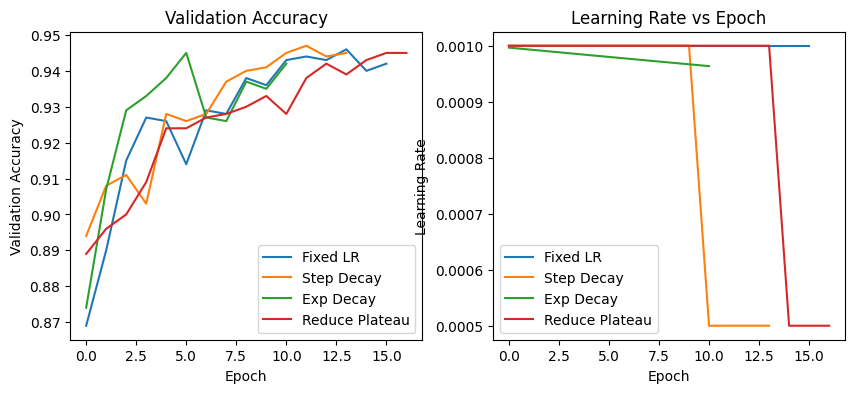

In [ ]:
plt.figure(figsize=(10,4))

# Accuracy Plot
plt.subplot(1,2,1)

plt.plot(hist_fixed.history["val_accuracy"], label="Fixed LR")
plt.plot(hist_step.history["val_accuracy"], label="Step Decay")
plt.plot(hist_exp.history["val_accuracy"], label="Exp Decay")
plt.plot(hist_plateau.history["val_accuracy"], label="Reduce Plateau")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy")
plt.legend()


# Learning Rate Plot
plt.subplot(1,2,2)

plt.plot(lr_fixed_rec.lrs, label="Fixed LR")
plt.plot(lr_step_rec.lrs, label="Step Decay")
plt.plot(lr_exp_rec.lrs, label="Exp Decay")
plt.plot(lr_plateau_rec.lrs, label="Reduce Plateau")

plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate vs Epoch")

plt.legend()

plt.show()

In [ ]:
print("Fixed LR:",
model_fixed.evaluate(x_test,y_test,verbose=0)[1])

print("Step Decay:",
model_step.evaluate(x_test,y_test,verbose=0)[1])

print("Exp Decay:",
model_exp.evaluate(x_test,y_test,verbose=0)[1])

print("Reduce Plateau:",
model_plateau.evaluate(x_test,y_test,verbose=0)[1])

Fixed LR: 0.9309999942779541
Step Decay: 0.9419999718666077
Exp Decay: 0.9399999976158142
Reduce Plateau: 0.9440000057220459
